# Clothing Item Classifier using CNN

Dataset: Fashion-MNIST

### Import Required Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


### Class Labels

In [3]:
class_names = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

### Explore the data

In [5]:
X_train.shape

(60000, 28, 28)

In [7]:
len(y_train)

60000

In [8]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [9]:
X_test.shape

(10000, 28, 28)

In [10]:
len(y_test)

10000

### Visualize Sample Images

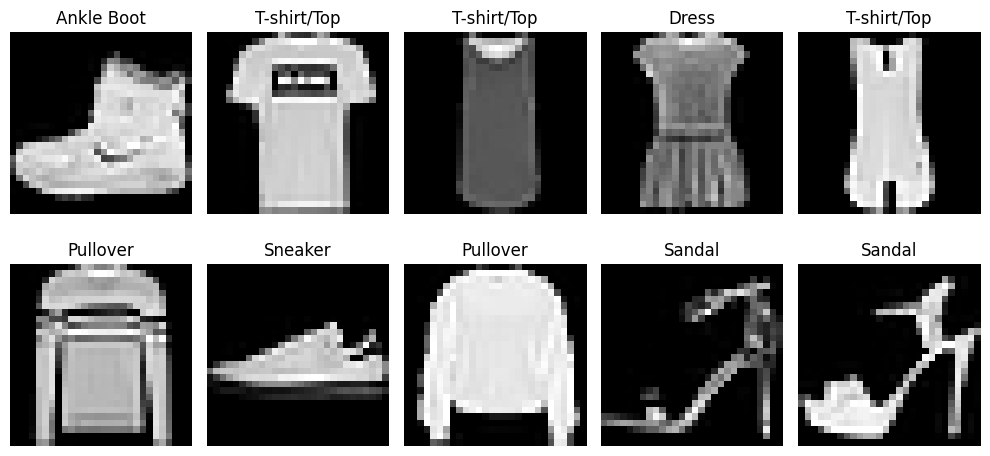

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Data Preprocessing

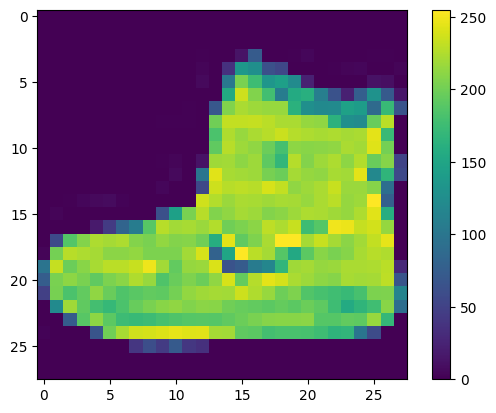

In [11]:
plt.figure()
plt.imshow(X_train[0])
plt.colorbar()
plt.grid(False)
plt.show()

### Normalize pixel values

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Reshape for CNN (add channel dimension)

CNN expects this format:
(samples, height, width, channels)

So you convert it to:
(60000, 28, 28, 1)

In [13]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

### One-hot encode labels

In [14]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### Build CNN Model

Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Dropout → Output

In [15]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

c:\Users\kwath\Documents\GitHub\Clothing-Item-Classifier-CNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compile Model

The `model.compile()` function prepares the neural network for training by defining how it will learn and be evaluated. It uses the Adam optimizer to efficiently update model weights during training. The categorical crossentropy loss function measures the error between predicted and actual class labels in multi-class problems. Additionally, accuracy is used as a metric to evaluate how well the model performs during training.


In [16]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7713 - loss: 0.6350 - val_accuracy: 0.8498 - val_loss: 0.4007
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8473 - loss: 0.4247 - val_accuracy: 0.8746 - val_loss: 0.3338
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8656 - loss: 0.3694 - val_accuracy: 0.8796 - val_loss: 0.3195
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8778 - loss: 0.3355 - val_accuracy: 0.8899 - val_loss: 0.2978
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8878 - loss: 0.3079 - val_accuracy: 0.8942 - val_loss: 0.2861
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8951 - loss: 0.2875 - val_accuracy: 0.9018 - val_loss: 0.2666
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8998 - loss: 0.2738 - val_accuracy: 0.9012 - val_loss: 0.2625
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9072 - loss: 0.2558 - 

### Evaluate Model

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9067 - loss: 0.2539
Test Accuracy: 0.9067000150680542


### Plot Accuracy & Loss Graphs

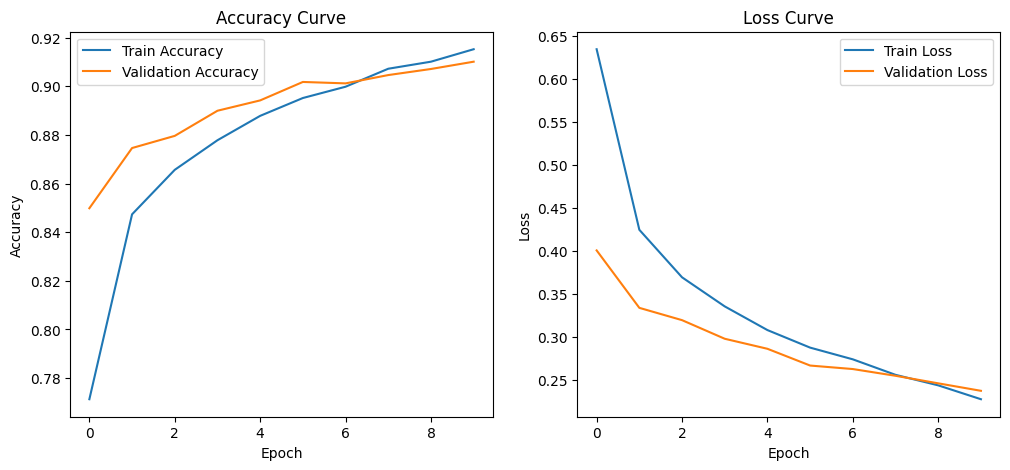

In [19]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


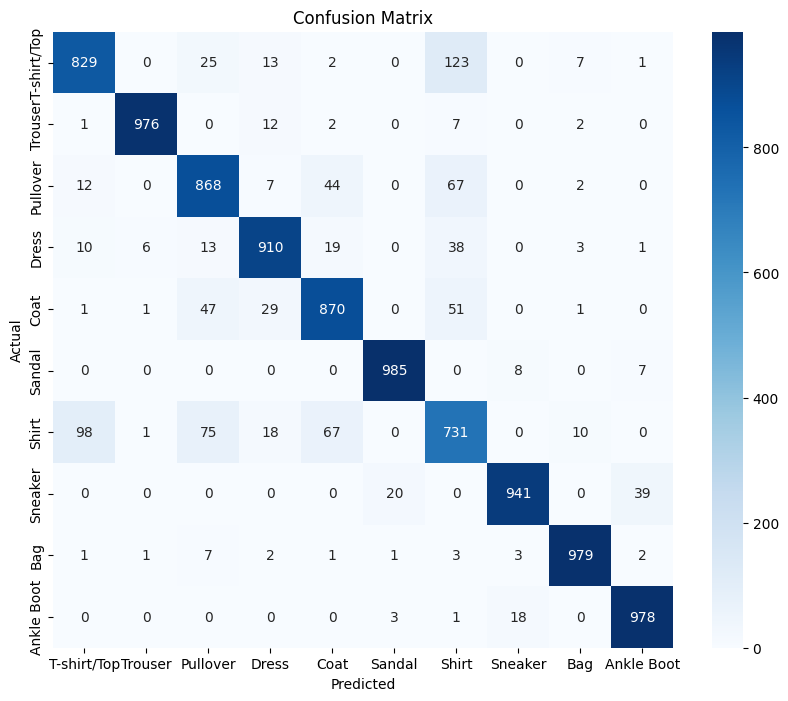

In [20]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [21]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/Top       0.87      0.83      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.84      0.87      0.85      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.87      0.87      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.73      0.72      1000
     Sneaker       0.97      0.94      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.95      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Save Model

In [23]:
model.save("../models/clothing_item_classifier_cnn.h5")